# Utah FORGE 2024: QuakeCastNet Training and Evaluation

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ.pop("SLURM_JOB_ID", None)
os.environ.pop("SLURM_NTASKS", None)
os.environ.pop("SLURM_JOB_NAME", None)
os.environ.pop("SLURM_NODELIST", None)
os.environ.setdefault("TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD", "1")
import re
import shutil
import random
import math
import warnings
from datetime import datetime, timedelta
warnings.filterwarnings("ignore")
import torch
torch.backends.cudnn.benchmark = True  

import glob, json as _json

In [2]:
import copy
from pathlib import Path
import warnings

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import ot

from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

In [3]:
from pytorch_forecasting import Baseline, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss, QuantileMaskLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.utils import WarmupSchedulerCallback
from pytorch_lightning.loggers import CSVLogger

from lightning.pytorch.callbacks import ModelCheckpoint

from models import TemporalFusionTransformerNew, CompositeQuantileLoss, RollingConfig, run_gated_recentered
from models.branchwise_transport_spatial import (
    BranchwiseTransportSpatialModel, BranchwiseTransportSpatialConfig,
    build_branchwise_transport_artifact,
)
from models.spatial_branch_eval import (
    load_catalog, load_dataset, events_to_cells, spatial_log_likelihood,
    kl_divergence, js_divergence,
)
import draw1, draw2, utils

## Load dataset

In [4]:
batch_size = 3072 
max_epochs = 100
model_save_epoch = 10
num_workers = 0
DO_TRAINING = False
precision = "32-true"
NM_SEEDS = [0, 1, 2]
NM_ALPHA = 0.0
n_enc = 800
n_dec = 320
downsample_rate = 4
max_prediction_length = n_dec // downsample_rate
max_encoder_length = n_enc // downsample_rate
print(f"max_prediction_length: {max_prediction_length}")
print(f"max_encoder_length: {max_encoder_length}")

# utahforge 2024
year, month, day, hour, minute = 2024, 4, 6, 6, 6
zero_date = datetime(year, month, day, hour, minute)
print(f"zero_date: {zero_date}")
zero_text = zero_date.strftime("%Y-%m-%d-%H-%M")

log_stem = f"i{max_encoder_length}o{max_prediction_length}t{zero_text}"
log_name = f"utahforge2024_{log_stem}"
print(f"log_name: {log_name}")

normm = "min_max"

max_prediction_length: 80
max_encoder_length: 200
zero_date: 2024-04-06 06:06:00
log_name: utahforge2024_i200o80t2024-04-06-06-06


In [5]:
def get_utahforge_segments(
    border1s, 
    border2s, 
    time_axis, 
    seismic_rate, 
    injection_rate, 
    injection_rate_grad, 
    pressure, 
    pressure_grad,
    w_len, n_len, max_encoder_length, max_prediction_length, w_step=1,
):
    border1, border2 = border1s[0], border2s[0] 
    
    train_data_list = []
    icount = 0
    for j0 in range(border1, border2+1, w_step):
        if j0 < 0:
            continue
        j1 = j0 + w_len
    
        if j1 > n_len:
            j0 = n_len - w_len
            j1 = n_len
            if j0 < 0:
                break

        date = np.array([x for x in time_axis[j0:j1]])
        data_dict = {
            'seismic_rate': seismic_rate[j0:j1],
            'pressure': pressure[j0:j1],
            'injection_rate': injection_rate[j0:j1],
            'pressure_grad': pressure_grad[j0:j1],
            'injection_rate_grad': injection_rate_grad[j0:j1],
            'date': date,
            'time_idx': np.arange(j1 - j0, dtype=np.int64),  
            'group_id': icount,
        }
                
        icount += 1
        train_data_list.append(data_dict)
        if j1 == n_len:
            break

    border1, border2 = border1s[1], border2s[1] 
    valid_data_list = []
    w_len = max_encoder_length + max_prediction_length
    for j0 in range(border1, border2+1, w_step):
        if j0 < 0:
            continue
        j1 = j0 + w_len
    
        if j1 > n_len:
            j0 = n_len - w_len
            j1 = n_len
            if j0 < 0:
                break

        date = np.array([x for x in time_axis[j0:j1]])
        data_dict = {
            'seismic_rate': seismic_rate[j0:j1],
            'pressure': pressure[j0:j1],
            'injection_rate': injection_rate[j0:j1],
            'pressure_grad': pressure_grad[j0:j1],
            'injection_rate_grad': injection_rate_grad[j0:j1],
            'date': date,
            'time_idx': np.arange(j1 - j0, dtype=np.int64),  
            'group_id': icount,
        }
                
        icount += 1
        valid_data_list.append(data_dict)
        if j1 == n_len:
            break
    return train_data_list, valid_data_list


def build_data_lists(
    data_dict,
    normm,
    downsample_rate,
    max_encoder_length,
    max_prediction_length,
    zero_date,
    w_step=1,
):
    import utils
    seismic_rate = data_dict['seis_rate']
    injection_rate = data_dict['inj_rate']
    pressure = data_dict['pres']
    injection_rate_grad = np.gradient(injection_rate)
    pressure_grad = np.gradient(pressure)
    time_axis = data_dict['time_axis']

    interval_seconds_original = int((time_axis[1] - time_axis[0]).total_seconds())
    print(f"interval_seconds_original: {interval_seconds_original}s")

    seismic_rate, injection_rate, injection_rate_grad, pressure, pressure_grad, norm_param = utils.normalize_features(
        seismic_rate,
        injection_rate,
        injection_rate_grad,
        pressure=pressure,
        pressure_grad=pressure_grad,
        normm=normm,
    )

    interval_seconds = downsample_rate * interval_seconds_original
    time_axis, seismic_rate, injection_rate, injection_rate_grad, pressure, pressure_grad = utils.downsample_time_series(
        time_axis, seismic_rate, injection_rate, injection_rate_grad, pressure, pressure_grad, 
        rule=f"{interval_seconds}S")

    print(f"time_axis: {len(time_axis)}")
    
    n_len = len(time_axis)
    w_len = max_encoder_length + max_prediction_length

    start_index = 0
    end_index = n_len - 1
    if zero_date is None:
        zero_index = end_index
    else:
        zero_index = np.where((time_axis >= zero_date) & (time_axis < zero_date + timedelta(seconds=interval_seconds)))[0][0]

    border1s = [start_index, zero_index - w_len]
    border2s = [zero_index - w_len, end_index]          

    # building training data
    train_data_list, valid_data_list = get_utahforge_segments(
        border1s, 
        border2s, 
        time_axis,
        seismic_rate, 
        injection_rate, 
        injection_rate_grad,
        pressure, 
        pressure_grad, 
        w_len, n_len, max_encoder_length, max_prediction_length, w_step=w_step)

    apply_data_list = valid_data_list[max_prediction_length:]
    valid_data_list = valid_data_list[:max_prediction_length]

    meta = {
        'time_axis': time_axis,
        'seismic_rate': seismic_rate,
        'injection_rate': injection_rate,
        'injection_rate_grad': injection_rate_grad,
        'pressure': pressure,
        'norm_param': norm_param,
    }
    return train_data_list, valid_data_list, apply_data_list, meta

In [6]:
# utahforge 2024
utahforge2024_path = os.path.join('preparation', 'dataset', 'UtahForge2024')
utahforge2024_dict = np.load(
    os.path.join(utahforge2024_path, 'seismic_inject_dataset2024_ext.npy'),
    allow_pickle=True
).item()

train_data_list2024, valid_data_list2024, apply_data_list2024, meta = build_data_lists(
    utahforge2024_dict,
    normm=normm,
    downsample_rate=downsample_rate,
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    zero_date=zero_date,
    w_step=1,
)

# utahforge 2022
utahforge2022_path = os.path.join('preparation', 'dataset', 'UtahForge2022')
utahforge2022_list = np.load(
    os.path.join(utahforge2022_path, 'seismic_inject_dataset2022.npy'),
    allow_pickle=True
).tolist()

train_data_list2022 = []
train_data_list, valid_data_list, _, _ = build_data_lists(
    utahforge2022_list[0],
    normm=normm,
    downsample_rate=downsample_rate,
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    zero_date=None,
    w_step=1,
)

train_data_list2022 += train_data_list 
train_data_list, valid_data_list, _, _ = build_data_lists(
    utahforge2022_list[1],
    normm=normm,
    downsample_rate=downsample_rate,
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    zero_date=None,
    w_step=1,
)
      
train_data_list2022 += train_data_list 
train_data_list, valid_data_list, _, _ = build_data_lists(
    utahforge2022_list[2],
    normm=normm,
    downsample_rate=downsample_rate,
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    zero_date=None,
    w_step=1,
)

train_data_list = train_data_list2024
valid_data_list = valid_data_list2024
apply_data_list = apply_data_list2024

_gid = 0
for seg in train_data_list + valid_data_list + apply_data_list:
    seg['group_id'] = _gid
    _gid += 1

for seg in train_data_list + valid_data_list + apply_data_list:
    _enc = seg['seismic_rate'][:max_encoder_length]
    seg['enc_seis_mean'] = float(_enc.mean())        # main anchor: encoder-segment target mean
    seg['enc_seis_tail20'] = float(_enc[-20:].mean()) # recent level: mean of last 20 encoder steps

print(f"Train Samples: {len(train_data_list)}")
print(f"Valid Samples: {len(valid_data_list)}")
print(f"Apply Samples: {len(apply_data_list)}")
print(f"Total unique group_ids: {_gid}")

interval_seconds_original: 120s
time_axis: 1244
interval_seconds_original: 120s
time_axis: 309
interval_seconds_original: 120s
time_axis: 309
interval_seconds_original: 120s
time_axis: 309
Train Samples: 167
Valid Samples: 80
Apply Samples: 719
Total unique group_ids: 966


1st Y-axis range: (np.float64(-0.04887820512820512), np.float64(1.0264423076923075))
2nd Y-axis range: (np.float64(-0.04992695000068567), np.float64(1.048465950014399))
3rd Y-axis range: (np.float64(-0.04995220649704273), np.float64(1.0489963364378974))


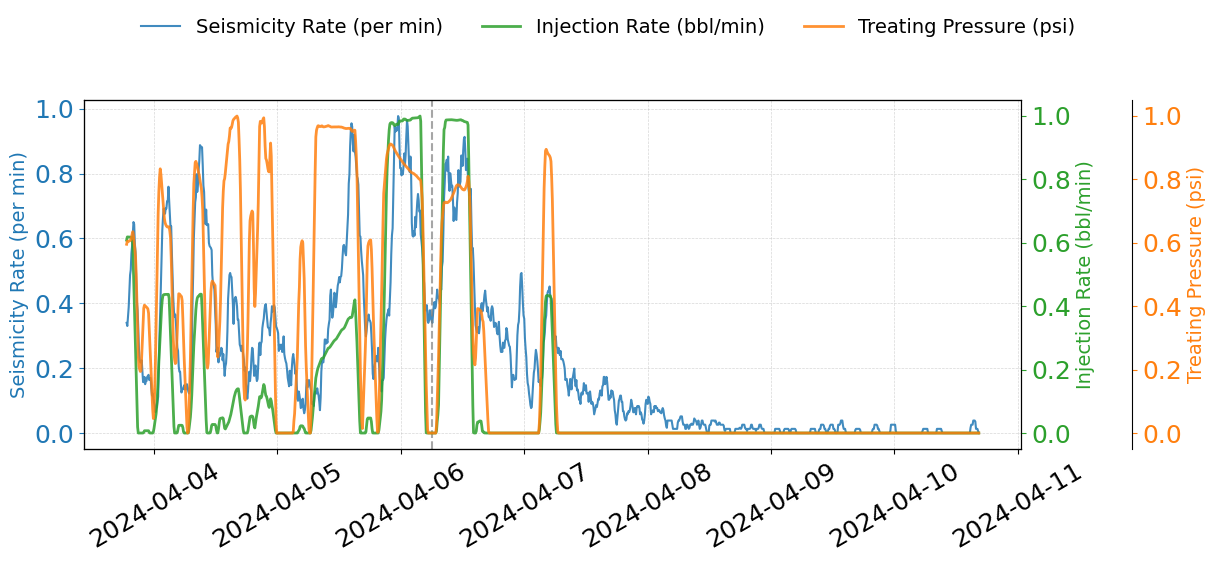

In [7]:
draw1.draw_sequence_diff(
    [
        [meta['time_axis'], meta['seismic_rate'],],
        [meta['time_axis'], meta['injection_rate'],],
        [meta['time_axis'], meta['pressure'],],
    ],
    mark_datetime = [zero_date],
    labels = ['Seismicity Rate (per min)', 'Injection Rate (bbl/min)', 'Treating Pressure (psi)'],
    figsize=(12,5),
)

In [8]:
target = "seismic_rate"
time_varying_known_reals = ["injection_rate", "pressure"]

train_data_set = utils.lists_to_df(train_data_list, target, time_varying_known_reals)
valid_data_set = utils.lists_to_df(valid_data_list, target, time_varying_known_reals)

apply_data_set = utils.lists_to_df(apply_data_list, target, time_varying_known_reals)

## Create dataloaders


In [9]:
from pytorch_forecasting import Baseline, TimeSeriesDataSet
from pytorch_forecasting.data.encoders import NaNLabelEncoder

training = TimeSeriesDataSet(
    train_data_set,
    time_idx="time_idx",
    target=target,
    group_ids=["group_id"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=[],
    static_reals=["enc_seis_mean", "enc_seis_tail20"],
    scalers={
        "enc_seis_mean": None,
        "enc_seis_tail20": None,
    },
    time_varying_known_categoricals=[],
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[target],
    categorical_encoders={      
        "group_id": NaNLabelEncoder(add_nan=True)
    },
    target_normalizer=None,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(training, valid_data_set, predict=True, stop_randomization=True)
application = TimeSeriesDataSet.from_dataset(training, apply_data_set, predict=True, stop_randomization=True)

# create dataloaders for model
loader_kwargs = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "pin_memory": True,
    "persistent_workers": num_workers > 0,
    "drop_last": False,
}
train_dataloader = training.to_dataloader(
    train=True,
    **loader_kwargs,
)
valid_dataloader = validation.to_dataloader(
    train=False,
    **loader_kwargs,
)
apply_dataloader = application.to_dataloader(
    train=False,
    **loader_kwargs,
)

## Train Temporal Fusion Transformer

In [10]:
if DO_TRAINING:
    for _seed in NM_SEEDS:
        _logger = CSVLogger("./logs/", name=log_name, version=f"seed_{_seed}")
        _ckpt_cb = ModelCheckpoint(dirpath=os.path.join(_logger.log_dir, "ckpts"),
                                   save_top_k=1, filename="{epoch}-{step}")
        
        num_training_samples = len(training)  
        steps_per_epoch = math.ceil(num_training_samples / batch_size)
        _steps = steps_per_epoch * max_epochs 
        _warmup_callback = WarmupSchedulerCallback(total_steps=_steps, warmup_fraction=0.03)
        
        _trainer = pl.Trainer(
            max_epochs=max_epochs, accelerator="gpu", devices=1, precision=precision,
            enable_model_summary=True,
            gradient_clip_val=0.1,
            callbacks=[LearningRateMonitor(), _ckpt_cb, _warmup_callback],
            logger=_logger,
        )
        
        _tft = TemporalFusionTransformerNew.from_dataset(
            training, learning_rate=0.03, hidden_size=64, attention_head_size=4,
            dropout=0.1, hidden_continuous_size=32,
            loss=CompositeQuantileLoss(alpha=NM_ALPHA),
            log_interval=10, optimizer="ranger", reduce_on_plateau_patience=4)        
        
        _trainer.fit(_tft, train_dataloaders=train_dataloader,
                     val_dataloaders=valid_dataloader)
        print(f"[nm2] seed {_seed} done")

## Evaluate Model Performance

In [11]:
log_path = os.path.join("./logs/", log_name)
version_list = [x for x in os.listdir(log_path) if x.startswith('version')]
version = sorted(version_list, key=lambda x:int(x.split('_')[-1]))[-1]

results_path = os.path.join(log_path, version)
os.makedirs(results_path, exist_ok=True)
print(f"results_path: {results_path}")

norm_stats = {
    key: np.asarray(list(value.values()))
    for key, value in meta["norm_param"].items()
}
time_axis_all = meta['time_axis'].copy()
interval_days = (meta['time_axis'][1] - meta['time_axis'][0]).total_seconds() / 86400.0
print(f"interval_days (downsampled): {interval_days:.6f} day = {interval_days*86400:.1f}s")

results_path: ./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0
interval_days (downsampled): 0.005556 day = 480.0s


In [12]:
NM_FT_LR, NM_FT_STEPS = 3e-3, 100

_cache17 = os.path.join(results_path, f"tft_results.npy")
if os.path.exists(_cache17):
    results_nm = np.load(_cache17, allow_pickle=True)
    print(f"[cache] results_nm={len(results_nm)} windows <- {_cache17}")
    
else:
    _nm_ckpts = []
    for _seed in NM_SEEDS:
        _c = sorted(glob.glob(f"./logs/{log_name}/seed_{_seed}/ckpts/*.ckpt"),
                    key=lambda x: int(x.split("=")[1].split("-")[0]))
        if _c:
            _nm_ckpts.append(_c[-1])
    print(f"[nm] ckpts (M={len(_nm_ckpts)}): {_nm_ckpts}")
    
    if len(_nm_ckpts) == len(NM_SEEDS):
        results_nm, _, _info = run_gated_recentered(
            RollingConfig(ft_lr=NM_FT_LR, ft_steps=NM_FT_STEPS,
                          alpha=0.1, batch_size=1024,
                          refit_every=1000),
            ckpt_paths=_nm_ckpts, training_template=training,
            train_data_list=train_data_list, apply_data_list=apply_data_list,
            target=target, known_reals=time_varying_known_reals,
            time_axis=time_axis_all,
            norm_stats=norm_stats)

        np.save(_cache17, np.array(results_nm, dtype=object))
        print(f"[saved] {_cache17} ({len(results_nm)} windows)")
    else:
        print("[nm] ckpts incomplete; run training first (DO_TRAINING_NM=True)")

[nm] ckpts (M=3): ['./logs/utahforge2024_i200o80t2024-04-06-06-06/seed_0/ckpts/epoch=99-step=1100.ckpt', './logs/utahforge2024_i200o80t2024-04-06-06-06/seed_1/ckpts/epoch=99-step=1100.ckpt', './logs/utahforge2024_i200o80t2024-04-06-06-06/seed_2/ckpts/epoch=99-step=1100.ckpt']


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[roll] batch 1/1 done (13s, ft=no) | ETA ~0 min


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[roll] batch 1/1 done (12s, ft=no) | ETA ~0 min
[saved] ./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_results.npy (719 windows)


In [13]:
_tft_name = "tft_results.npy"
_nsd_name = _tft_name.replace("results", "shutin_results")

_cache_nsd = os.path.join(results_path, _nsd_name)
if os.path.exists(_cache_nsd):
    results_new_decay = np.load(_cache_nsd, allow_pickle=True)
    print(f"[cache] loaded results_new_decay: {len(results_new_decay)} windows <- {_cache_nsd}")
else:
    from models.shutin_decay_tft import ShutInDecayEstimator, apply_correction
    from models.verify_shutin_decay import load_raw_series, THRESHOLD_BBL, STEP_HOURS

    _res_new = np.load(os.path.join(results_path, _tft_name), allow_pickle=True)

    seis_raw = np.asarray(meta['seismic_rate'], float) * norm_stats['seismic_rate'][1]
    inj_raw = np.asarray(meta['injection_rate'], float) * norm_stats['injection_rate'][1]
    seis_range = float(norm_stats['seismic_rate'][1])
    zero_index = int(np.where(time_axis_all >= zero_date)[0][0])
    _seis2min = np.asarray(utahforge2024_dict['seis_rate'], float)
    _ta2min = utahforge2024_dict['time_axis']
    _zi2min = int(np.searchsorted(np.array([np.datetime64(t) for t in _ta2min]),
                                  np.datetime64(zero_date)))
    _pos = np.unique(_seis2min[:_zi2min][_seis2min[:_zi2min] > 0])
    _dif = np.diff(_pos)
    _quantum = float(_dif[_dif > 1e-9].min()) if len(_pos) >= 2 else (
        float(_pos[0]) if len(_pos) else None)

    est = ShutInDecayEstimator(threshold_bbl=THRESHOLD_BBL, step_hours=STEP_HOURS,
                               detection_quantum=_quantum)
    _l2022 = np.load(os.path.join('preparation', 'dataset', 'UtahForge2022',
                                  'seismic_inject_dataset2022.npy'),
                     allow_pickle=True).tolist()
    for _seg in _l2022:
        _, _seis22, _inj22, _ = load_raw_series(_seg)
        est.add_pool_segment(_inj22, _seis22)
    est.set_application_series(inj_raw, seis_raw, zero_index)
    _origins = zero_index + np.arange(len(_res_new))
    _wcs = est.fit_windows(_origins)

    _tgt0 = np.asarray(_res_new[0]['target'], float)
    assert np.allclose(_tgt0, seis_raw[_origins[0]:_origins[0] + len(_tgt0)],
                       rtol=1e-3, atol=1e-4), "window 0 alignment check failed: origin mismatch"
    _tgtL = np.asarray(_res_new[-1]['target'], float)
    assert np.allclose(_tgtL, seis_raw[_origins[-1]:_origins[-1] + len(_tgtL)],
                       rtol=1e-3, atol=1e-4), "last window alignment check failed: origin mismatch"

    _off = float(norm_stats['seismic_rate'][0])
    _scale = float(norm_stats['seismic_rate'][1])
    _pred_z = np.stack([(np.asarray(rd['prediction'], float) - _off) / _scale
                        for rd in _res_new])
    
    _pred_z_c = apply_correction(_pred_z, _wcs, est, seis_range)

    results_new_decay = []
    for _i, rd in enumerate(_res_new):
        rd2 = dict(rd)
        rd2['prediction'] = _pred_z_c[_i] * _scale + _off
        results_new_decay.append(rd2)
    np.save(_cache_nsd, np.array(results_new_decay, dtype=object))
    print(f"[saved] results_new_decay -> {_cache_nsd}")

[saved] results_new_decay -> ./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_shutin_results.npy


In [14]:
# Load cached results
cache_files = {
    "results_new": os.path.join(
        results_path,
        "tft_shutin_results.npy",
    ),
}

for var_name, path in cache_files.items():
    if os.path.exists(path):
        print(path)
        globals()[var_name] = np.load(path, allow_pickle=True)

results_sets = {
    "current": results_new, 
    
}

./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_shutin_results.npy


## Forecast Skill Comparison

In [15]:
_fsc_required = ['results_path', 'meta', 'norm_stats', 'zero_date',
                 'max_prediction_length', 'interval_days']
_fsc_missing = [name for name in _fsc_required if name not in globals()]
if _fsc_missing:
    raise RuntimeError('Run the data-loading and results-path cells first. Missing: ' + ', '.join(_fsc_missing))

def _fsc_validate_results(label, candidate, reference=None):
    if len(candidate) == 0:
        raise ValueError(f'{label} contains no forecast windows.')
    if reference is not None and len(candidate) != len(reference):
        raise ValueError(f'{label} has a different window count from current. Regenerate its cache.')
    for i, rd in enumerate(candidate):
        target_values = np.asarray(rd['target'], dtype=float)
        pred_values = np.asarray(rd['prediction'], dtype=float)
        indices = np.asarray(rd['target_index'], dtype=int)
        if target_values.shape != (max_prediction_length,) or indices.shape != target_values.shape:
            raise ValueError(f'{label} window {i} has an invalid target length.')
        if pred_values.ndim not in (1, 2) or pred_values.shape[0] != len(target_values):
            raise ValueError(f'{label} window {i} has an invalid prediction shape.')
        if not np.isfinite(target_values).all() or not np.isfinite(pred_values).all():
            raise ValueError(f'{label} window {i} contains non-finite targets or predictions.')
        if reference is not None:
            ref = reference[i]
            ref_indices = np.asarray(ref['target_index'], dtype=int)
            same_dates = np.array_equal(
                np.asarray(rd['date'], dtype='datetime64[ns]')[indices],
                np.asarray(ref['date'], dtype='datetime64[ns]')[ref_indices])
            if not same_dates or not np.array_equal(target_values, np.asarray(ref['target'], dtype=float)):
                raise ValueError(f'{label} window {i} is not aligned with current. Regenerate its cache.')

_fsc_current_cache = Path(results_path) / 'tft_shutin_results.npy'
_fsc_nof_cache = Path(results_path) / 'tft_nofuture_results.npy'
_fsc_nod_cache = Path(results_path) / 'tft_results.npy'
for _fsc_cache in [_fsc_current_cache, _fsc_nod_cache, _fsc_nof_cache]:
    if not _fsc_cache.is_file():
        raise FileNotFoundError(f'Missing forecast cache: {_fsc_cache.resolve()}. Generate these forecasts first.')
_fsc_meta_times = pd.DatetimeIndex(meta['time_axis'])
if not _fsc_meta_times.is_unique or not _fsc_meta_times.is_monotonic_increasing:
    raise ValueError('The metadata time axis must be unique and increasing.')
_fsc_interval_days = (_fsc_meta_times[1] - _fsc_meta_times[0]).total_seconds() / 86400.0
if not np.allclose(np.diff(_fsc_meta_times.asi8) / 86400e9, _fsc_interval_days):
    raise ValueError('The metadata time axis must have a constant time step.')
_fsc_grad_raw = (np.asarray(meta['injection_rate_grad'], dtype=float)
                 * norm_stats['injection_rate_grad'][1] + norm_stats['injection_rate_grad'][0])
_fsc_seis_raw = (np.asarray(meta['seismic_rate'], dtype=float)
                 * norm_stats['seismic_rate'][1] + norm_stats['seismic_rate'][0])
if _fsc_grad_raw.shape != (len(_fsc_meta_times),):
    raise ValueError('The metadata injection gradient must be one-dimensional.')

def _fsc_load_results(cache_path):
    raw = np.load(cache_path, allow_pickle=True)
    aligned = []
    repaired = 0
    for i, rd in enumerate(raw):
        dates = pd.DatetimeIndex(rd['date'])
        indices = _fsc_meta_times.get_indexer(dates)
        if np.any(indices < 0) or not np.all(np.diff(indices) == 1):
            raise ValueError(f'{cache_path.name} window {i} is not aligned with metadata dates.')
        target_indices = np.asarray(rd['target_index'], dtype=int)
        if not np.allclose(np.asarray(rd['target'], dtype=float),
                           _fsc_seis_raw[indices[target_indices]], rtol=1e-5, atol=1e-7):
            raise ValueError(f'{cache_path.name} window {i} has targets inconsistent with metadata.')
        new = dict(rd)
        new['date_index'] = indices
        if np.asarray(rd['injection_rate_grad']).shape != (len(dates),):
            repaired += 1
        new['injection_rate_grad'] = _fsc_grad_raw[indices].copy()
        aligned.append(new)
    print(f'[loaded] {len(aligned)} windows <- {cache_path}; rebuilt {repaired} invalid gradient arrays in memory')
    return aligned

results_new = _fsc_load_results(_fsc_current_cache)
results_nod = _fsc_load_results(_fsc_nod_cache)
results_nof = _fsc_load_results(_fsc_nof_cache)
_fsc_validate_results('current', results_new)
_fsc_validate_results('nod', results_nod, results_new)
_fsc_validate_results('nof', results_nof, results_new)
results = results_new
_fsc_fit_mask = np.asarray(meta['time_axis'], dtype='datetime64[ns]') < pd.Timestamp(zero_date).to_datetime64()
if _fsc_fit_mask.sum() < 2:
    raise ValueError('Insufficient fitting data before zero_date.')
print(f'[current] {len(results_new)} windows <- {_fsc_current_cache}')
print(f'[nof] {len(results_nof)} windows <- {_fsc_nof_cache}')
print(f'[nod] {len(results_nod)} windows <- {_fsc_nod_cache}')
print(f'Time step: {_fsc_interval_days * 1440:g} minutes; forecast horizon: {max_prediction_length} steps')

[loaded] 719 windows <- logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_shutin_results.npy; rebuilt 719 invalid gradient arrays in memory
[loaded] 719 windows <- logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_results.npy; rebuilt 719 invalid gradient arrays in memory
[loaded] 719 windows <- logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_nofuture_results.npy; rebuilt 719 invalid gradient arrays in memory
[current] 719 windows <- logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_shutin_results.npy
[nof] 719 windows <- logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_nofuture_results.npy
[nod] 719 windows <- logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/tft_results.npy
Time step: 8 minutes; forecast horizon: 80 steps


In [16]:
_cache_gbdt = os.path.join(results_path, "gbdt_pz_results.npy")
if os.path.exists(_cache_gbdt):
    results_gbdt = np.load(_cache_gbdt, allow_pickle=True)
    print(f"[cache] results_gbdt={len(results_gbdt)} windows <- {_cache_gbdt}")
else:
    _denorm = lambda k, a: np.asarray(a, float) * norm_stats[k][1] + norm_stats[k][0]
    _dk = ["injection_rate"] + (["pressure"] if results[0].get("pressure") is not None else []) + ["injection_rate_grad"]
    hist_seis_pz = _denorm('seismic_rate', meta['seismic_rate'])[_fsc_fit_mask]
    hist_drv_pz = [_denorm(k, meta[k])[_fsc_fit_mask] for k in _dk]
    _gbdt_model = utils.fit_gbdt_model(hist_seis_pz, hist_drv_pz)
    print(f"GBDT: pre-zero fit completed ({int(_fsc_fit_mask.sum())} bins)")

    results_gbdt = []
    for rd in results:
        seis_last = np.asarray(rd['seismic_rate'], float)[rd['target_index'][0] - 1]
        drv_future = [np.asarray(rd[k], float)[rd['target_index']] for k in _dk]
        pred_gbdt = utils.predict_gbdt_frozen(_gbdt_model, seis_last, drv_future, max_prediction_length)
        new = dict(rd)
        new['prediction'] = pred_gbdt
        results_gbdt.append(new)
    print(f"results_gbdt: {len(results_gbdt)} windows, prediction shape={results_gbdt[0]['prediction'].shape}")
    os.makedirs(os.path.dirname(_cache_gbdt), exist_ok=True)
    np.save(_cache_gbdt, results_gbdt)
    print(f"[saved] results_gbdt -> {_cache_gbdt}")

[cache] results_gbdt=719 windows <- ./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/gbdt_pz_results.npy


In [17]:
get_inputs_etas = utils.prepare_baseline_inputs(
    results=results,
    meta=meta,
    norm_stats=norm_stats,
    max_prediction_length=max_prediction_length,
    use_full_history=True,
)
window_size, step_size = 8, 2

_cache23 = os.path.join(results_path, "etas_pz_results.npy")
if os.path.exists(_cache23):
    results_etas = np.load(_cache23, allow_pickle=True)
    print(f"[cache] results_etas={len(results_etas)} windows <- {_cache23}")

else:
    results_etas = utils.run_etas_frozen(
        "etas", results, get_inputs_etas,
        fit_rate=(np.asarray(meta['seismic_rate'], float) * norm_stats['seismic_rate'][1] + norm_stats['seismic_rate'][0])[_fsc_fit_mask],
        fit_inj=None,
        max_pred_len=max_prediction_length, dt=_fsc_interval_days,
        window_size=window_size, step_size=step_size,
        driver_keys=["injection_rate"] + (["pressure"] if results[0].get("pressure") is not None else []) + ["injection_rate_grad"],
        use_parallel=False, progress_name=None,
    )
    print(f"results_etas: {len(results_etas)} windows, prediction shape={results_etas[0]['prediction'].shape}")
    os.makedirs(os.path.dirname(_cache23), exist_ok=True)
    np.save(_cache23, results_etas)
    print(f"[saved] results_etas -> {_cache23}")

[cache] results_etas=719 windows <- ./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/etas_pz_results.npy


In [18]:
_cache24 = os.path.join(results_path, "etas_mancini_pz_results.npy")
if os.path.exists(_cache24):
    results_etas_mancini = np.load(_cache24, allow_pickle=True)
    print(f"[cache] results_etas_mancini={len(results_etas_mancini)} windows <- {_cache24}")
else:

    _denorm = lambda k, a: np.asarray(a, float) * norm_stats[k][1] + norm_stats[k][0]
    results_etas_mancini = utils.run_etas_frozen(
        "mancini", results, get_inputs_etas,
        fit_rate=_denorm('seismic_rate', meta['seismic_rate'])[_fsc_fit_mask],
        fit_inj=_denorm('injection_rate', meta['injection_rate'])[_fsc_fit_mask],
        max_pred_len=max_prediction_length, dt=_fsc_interval_days,
        window_size=window_size, step_size=step_size,
        driver_keys=["injection_rate"] + (["pressure"] if results[0].get("pressure") is not None else []) + ["injection_rate_grad"],
        use_parallel=False, progress_name=None,
    )
    print(f"results_etas_mancini: {len(results_etas_mancini)} windows, prediction shape={results_etas_mancini[0]['prediction'].shape}")
    os.makedirs(os.path.dirname(_cache24), exist_ok=True)
    np.save(_cache24, results_etas_mancini)
    print(f"[saved] results_etas_mancini -> {_cache24}")

[cache] results_etas_mancini=719 windows <- ./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/etas_mancini_pz_results.npy


In [19]:
_cache25 = os.path.join(results_path, "etas_kim_pz_results.npy")
if os.path.exists(_cache25):
    results_etas_kim = np.load(_cache25, allow_pickle=True)
    print(f"[cache] results_etas_kim={len(results_etas_kim)} windows <- {_cache25}")
else:

    _denorm = lambda k, a: np.asarray(a, float) * norm_stats[k][1] + norm_stats[k][0]
    results_etas_kim = utils.run_etas_frozen(
        "kim", results, get_inputs_etas,
        fit_rate=_denorm('seismic_rate', meta['seismic_rate'])[_fsc_fit_mask],
        fit_inj=_denorm('injection_rate', meta['injection_rate'])[_fsc_fit_mask],
        max_pred_len=max_prediction_length, dt=_fsc_interval_days,
        driver_keys=["injection_rate"] + (["pressure"] if results[0].get("pressure") is not None else []) + ["injection_rate_grad"],
        use_parallel=False, progress_name=None,
    )
    print(f"results_etas_kim: {len(results_etas_kim)} windows, prediction shape={results_etas_kim[0]['prediction'].shape}")
    os.makedirs(os.path.dirname(_cache25), exist_ok=True)
    np.save(_cache25, results_etas_kim)
    print(f"[saved] results_etas_kim -> {_cache25}")

[cache] results_etas_kim=719 windows <- ./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/etas_kim_pz_results.npy


In [20]:
_cache26 = os.path.join(results_path, "etas_global_pz_results.npy")
if os.path.exists(_cache26):
    results_etas_global = np.load(_cache26, allow_pickle=True)
    print(f"[cache] results_etas_global={len(results_etas_global)} windows <- {_cache26}")
else:

    _denorm = lambda k, a: np.asarray(a, float) * norm_stats[k][1] + norm_stats[k][0]
    results_etas_global = utils.run_etas_frozen(
        "etas_global", results, get_inputs_etas,
        fit_rate=_denorm('seismic_rate', meta['seismic_rate'])[_fsc_fit_mask],
        fit_inj=None,
        max_pred_len=max_prediction_length, dt=_fsc_interval_days,
        driver_keys=["injection_rate"] + (["pressure"] if results[0].get("pressure") is not None else []) + ["injection_rate_grad"],
        use_parallel=False, progress_name=None,
    )
    print(f"results_etas_global: {len(results_etas_global)} windows, prediction shape={results_etas_global[0]['prediction'].shape}")
    os.makedirs(os.path.dirname(_cache26), exist_ok=True)
    np.save(_cache26, results_etas_global)
    print(f"[saved] results_etas_global -> {_cache26}")

[cache] results_etas_global=719 windows <- ./logs/utahforge2024_i200o80t2024-04-06-06-06/version_0/etas_global_pz_results.npy


In [21]:
results_sets = {
    "current": results_new,
    "gbdt": results_gbdt,
    "etas": results_etas,
    "etas_global": results_etas_global,
    "etas_mancini": results_etas_mancini,
    "etas_kim": results_etas_kim,
    "nod": results_nod,
    "nof": results_nof,
}

window_metric_names = [
    "RMSE",
    "MAE",
    "Pearson_correlation",
    "Cosine_similarity",
    "SMAPE_%",
]

for _fsc_name, _fsc_results in results_sets.items():
    _fsc_validate_results(_fsc_name, _fsc_results, results_new)
all_window = utils.compute_all_window_metrics(
    results_sets=results_sets, window_metric_names=window_metric_names,
)
for _fsc_name, (_fsc_starts, _fsc_metrics) in all_window.items():
    if not np.array_equal(_fsc_starts, all_window['current'][0]):
        raise ValueError(f'{_fsc_name} has a different window order from current.')
print(f'Computed five metrics for {len(all_window)} models, with {len(results_new)} windows per model.')

Computed five metrics for 8 models, with 719 windows per model.


In [22]:
early_frac = 0.25

_lower_better = {"RMSE", "MAE", "SMAPE_%"}
_score_models = list(all_window.keys())

_score_start = np.asarray(all_window['current'][0])
_score_order = np.argsort(_score_start, kind="stable")
n_windows = len(_score_start)
n_early = max(1, int(round(early_frac * n_windows)))
early_idx = _score_order[:n_early]

_G = []
for mn in window_metric_names:
    M = np.column_stack([all_window[m][1][mn] for m in _score_models])
    M[~np.isfinite(M)] = np.nan
    vmin = np.nanmin(M, axis=1, keepdims=True)
    vmax = np.nanmax(M, axis=1, keepdims=True)
    rng = np.where(vmax - vmin > 0, vmax - vmin, 1.0)
    G = (vmax - M) / rng if mn in _lower_better else (M - vmin) / rng
    G[~np.isfinite(M)] = np.nan
    _G.append(G)
combined_score = np.nanmean(np.stack(_G, axis=0), axis=0)

score_df = pd.DataFrame({
    'model': _score_models,
    'overall_mean': np.nanmean(combined_score, axis=0),
    'overall_median': np.nanmedian(combined_score, axis=0),
    f'early{n_early}_mean': np.nanmean(combined_score[early_idx], axis=0),
    f'early{n_early}_median': np.nanmedian(combined_score[early_idx], axis=0),
}).sort_values(f'early{n_early}_mean', ascending=False).reset_index(drop=True)

print(f"Combined score is in [0, 1]; higher is better. Early windows: the first {n_early} of {n_windows} forecast origins.")
print(f"Forecast start range: {_score_start[_score_order[0]]} ~ {_score_start[_score_order[-1]]}")
display(score_df)

rows = {}
for m in _score_models:
    row = {}
    for mn in window_metric_names:
        v = all_window[m][1][mn]
        row[mn] = np.nanmean(v)
        row[f'{mn}_early'] = np.nanmean(v[early_idx])
    rows[m] = row
metric_df = pd.DataFrame(rows).T
display(metric_df)

_fsc_window_rows = []
for _fsc_j, _fsc_name in enumerate(_score_models):
    _fsc_starts, _fsc_metrics = all_window[_fsc_name]
    for _fsc_i, _fsc_start in enumerate(_fsc_starts):
        _fsc_window_rows.append({
            'model': _fsc_name, 'window': _fsc_i, 'forecast_start': _fsc_start,
            'early': bool(_fsc_i in early_idx),
            **{mn: float(_fsc_metrics[mn][_fsc_i]) for mn in window_metric_names},
            'combined_score': float(combined_score[_fsc_i, _fsc_j]),
        })
fsc_window_metrics = pd.DataFrame(_fsc_window_rows)

Combined score is in [0, 1]; higher is better. Early windows: the first 180 of 719 forecast origins.
Forecast start range: 2024-04-06 06:08:00 ~ 2024-04-10 05:52:00


,model,overall_mean,overall_median,early180_mean,early180_median
0,nod,0.696314,0.645991,0.985510,0.997223
1,current,0.861837,0.861407,0.974415,0.990083
2,gbdt,0.593782,0.588600,0.740950,0.728275
3,etas,0.378125,0.365105,0.621406,0.579832
4,etas_mancini,0.759241,0.787682,0.611082,0.649123
5,etas_kim,0.742281,0.786204,0.519802,0.522202
6,nof,0.681803,0.710335,0.499675,0.480660
7,etas_global,0.166899,0.126963,0.251990,0.210879


,RMSE,RMSE_early,MAE,MAE_early,Pearson_correlation,Pearson_correlation_early,Cosine_similarity,Cosine_similarity_early,SMAPE_%,SMAPE_%_early
current,0.052651,0.118998,0.044040,0.097465,0.362121,0.756433,0.743052,0.973473,75.371771,27.561529
gbdt,0.191501,0.215637,0.179820,0.175758,0.131282,0.685289,0.792611,0.948441,124.427654,44.230736
etas,0.391090,0.243458,0.379608,0.200095,-0.071344,0.174568,0.787167,0.926296,141.584757,46.855167
etas_global,0.529857,0.389663,0.523729,0.368377,-0.314268,-0.474585,0.783643,0.922183,152.276942,70.289720
etas_mancini,0.076317,0.232326,0.064024,0.197219,0.344168,0.536721,0.786906,0.930117,101.209875,61.052190
etas_kim,0.166177,0.474331,0.153564,0.434274,0.362767,0.664180,0.802963,0.958629,107.831019,66.350709
nod,0.190144,0.118192,0.183350,0.097162,0.374975,0.777225,0.805276,0.974808,123.631001,27.474103
nof,0.100880,0.238204,0.086886,0.195440,-0.082184,-0.469587,0.721920,0.904325,85.828650,45.665540


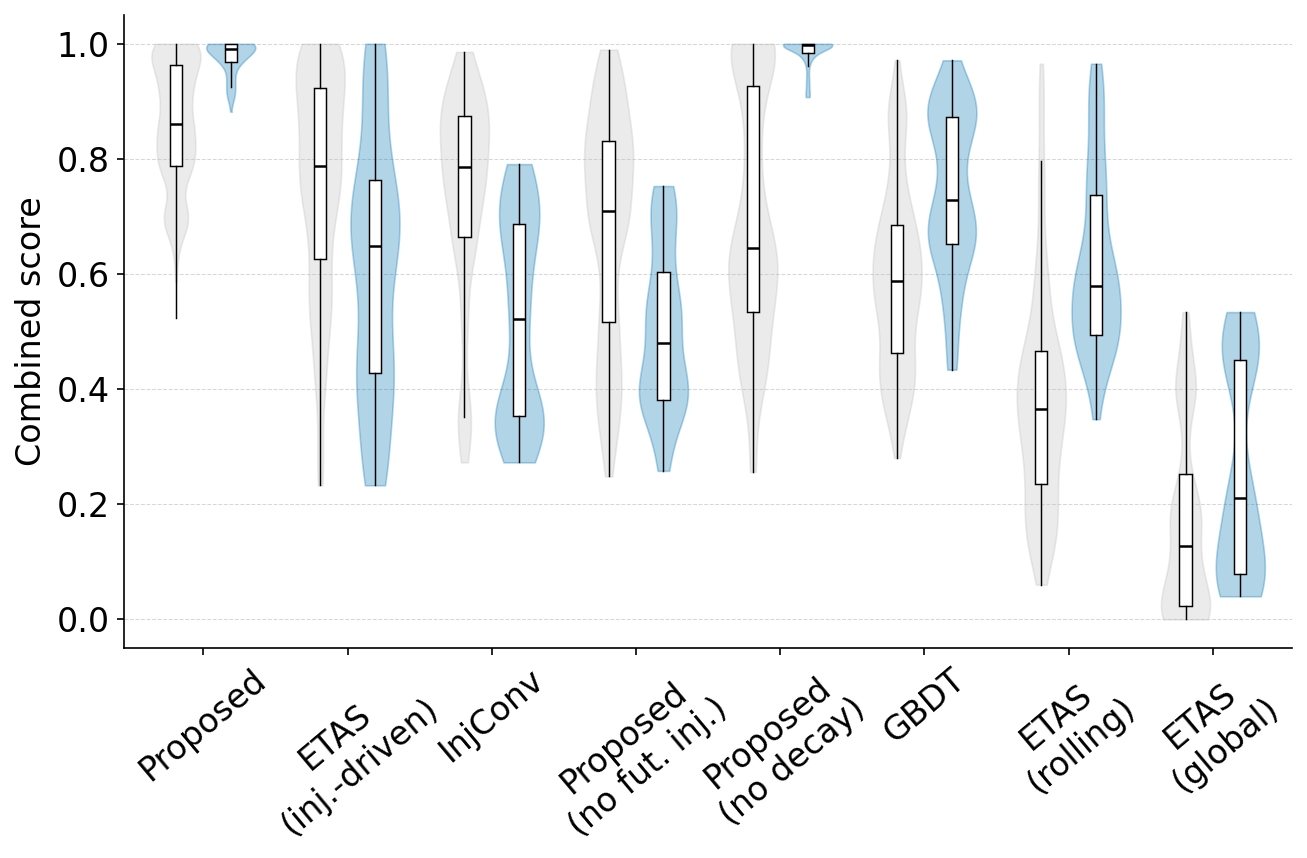

In [23]:
assert combined_score.shape == (n_windows, len(_score_models))
all_window_viz = {
    m: (all_window[m][0], {**all_window[m][1], 'combined_score': combined_score[:, j]})
    for j, m in enumerate(_score_models)
}
MODEL_LABELS = {
    'current': 'Proposed',
    'nof': 'Proposed\n(no fut. inj.)',
    'nod': 'Proposed\n(no decay)',
    'gbdt': 'GBDT',
    'etas': 'ETAS\n(rolling)',
    'etas_global': 'ETAS\n(global)',
    'etas_mancini': 'ETAS\n(inj.-driven)',
    'etas_kim': 'InjConv',
}
assert set(MODEL_LABELS) == set(all_window_viz)
fig_combined, ax_combined = draw2.plot_metric_violins(
    all_window_viz, 'combined_score', early_idx,
    model_labels=MODEL_LABELS,
    ylabel='Combined score', lower_better=False, legand=False,
    figsize=(9, 6), rotation=40,
)
plt.show()

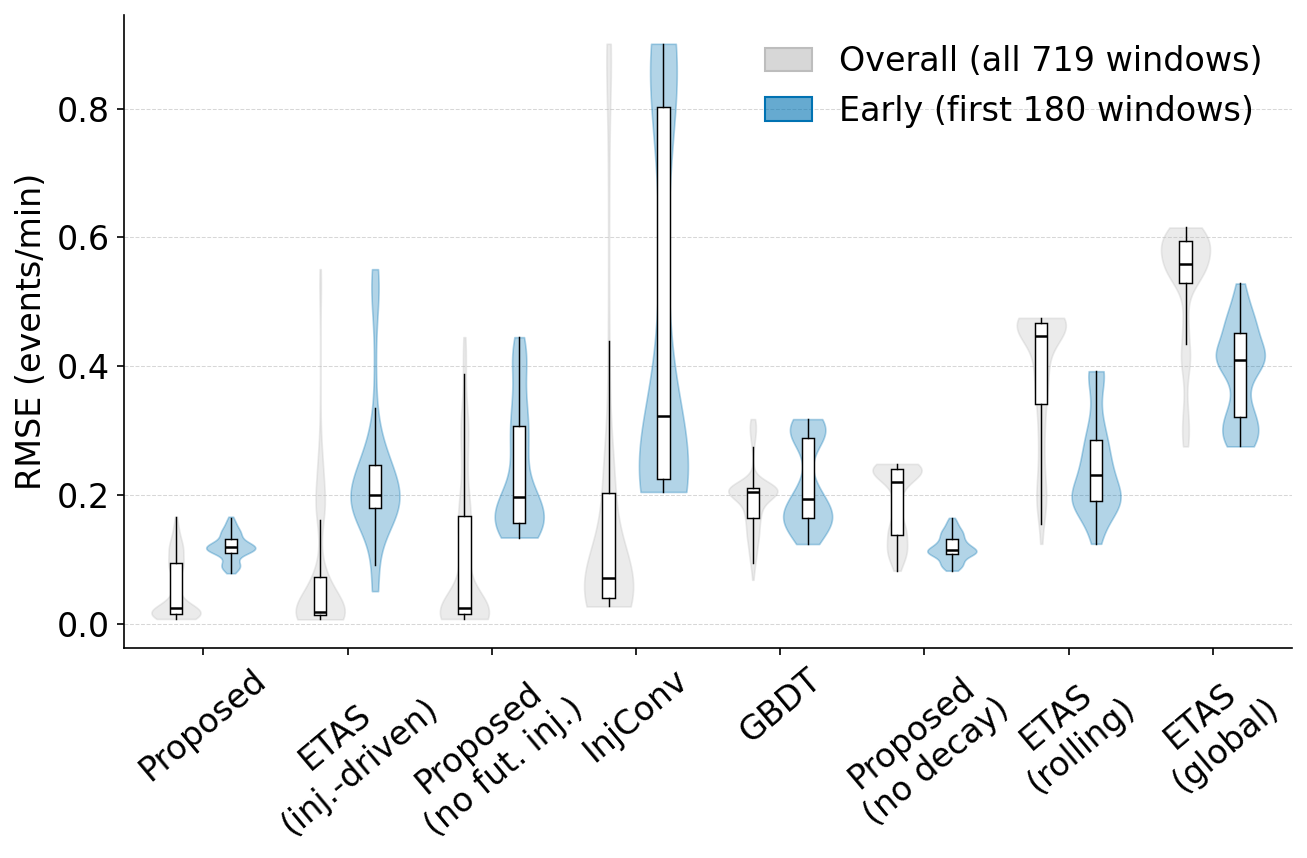

In [24]:
fig_rmse, ax_rmse = draw2.plot_metric_violins(
    all_window_viz, 'RMSE', early_idx,
    model_labels=MODEL_LABELS,
    ylabel='RMSE (events/min)', lower_better=True, legand=True,
    figsize=(9, 6), rotation=40,
)
plt.show()

## Spatial Distribution of Seismicity

In [25]:
sp_catalog = load_catalog(os.path.join(
    'preparation', 'raw_data', 'UtahForge2024', 'utahforge2024_catalog_processed.csv'))
_sp_dataset = load_dataset(os.path.join(
    'preparation', 'dataset', 'UtahForge2024', 'seismic_inject_dataset2024_ext.npy'))

sw_grid = _sp_dataset['sw_grid']
injection_times_sp = np.asarray(_sp_dataset['time_axis'], dtype='datetime64[ns]')
injection_values_sp = np.asarray(_sp_dataset['inj_rate'], dtype=np.float64)
n_grid = int(sw_grid['n_grid'])
n_cells = n_grid * n_grid

_well_data = np.load(os.path.join(
    'preparation', 'raw_data', 'UtahForge2024', 'utahforge2024_well_processed.npy'),
    allow_pickle=True).item()
_s = _well_data['stages']
_stage_context = []
for _i in range(len(_s['zone'])):
    if _s['well'][_i] != '16A' or not bool(_s['overlaps_dataset'][_i]):
        continue
    _stage_context.append(dict(
        stage_id=f"16A-z{int(_s['zone'][_i])}-{_i}", order=_i,
        lat=float(_s['lat'][_i]), lon=float(_s['lon'][_i]),
        start=str(_s['t_start'][_i]), end=str(_s['t_end'][_i]),
        knowledge_time='2024-04-03T00:00:00'))

_artifact = build_branchwise_transport_artifact(
    sw_grid, sp_catalog['lats'], sp_catalog['lons'],
    sp_catalog['mags'], sp_catalog['times'],
    cutoff='2024-04-06T06:00:00',
    injection_times=injection_times_sp, injection_values=injection_values_sp,
    stages=_stage_context)

sp_model = BranchwiseTransportSpatialModel(
    sw_grid, artifact=_artifact, stages=_stage_context,
    config=BranchwiseTransportSpatialConfig(
        tau_days=0.5,
        active_tau_days=0.05,
        variant='unsharpened',
        kde_bandwidth_floor_km=0.05,
        kde_bandwidth_scale_km=0.05,
        gamma=1.5,
        beta=0.3,
    ))

results = results_sets["current"]
H = len(results[0]['prediction'])
n_enc_sp = len(results[0]['date']) - H
dt_bin = pd.Timedelta(results[0]['date'][1] - results[0]['date'][0])
bin_mins = dt_bin.total_seconds() / 60.0

sp_windows = []
for k, r in enumerate(results):
    pred = np.asarray(r['prediction'], dtype=np.float64)
    if pred.ndim == 2:
        pred = pred.mean(axis=1)
    t_issue = pd.Timestamp(r['date'][n_enc_sp - 1])
    sp_windows.append({
        'k': k,
        't_issue': t_issue,
        'fw_end': t_issue + H * dt_bin,
        'pred': pred,
        'N_pred': float(np.clip(pred, 0.0, None).sum() * bin_mins),
    })

In [26]:
cat_lats, cat_lons = sp_catalog['lats'], sp_catalog['lons']
cat_mags, cat_times = sp_catalog['mags'], sp_catalog['times']
lat_edges = np.asarray(sw_grid['lat_edges'])
lon_edges = np.asarray(sw_grid['lon_edges'])
log_unif = np.log(1.0 / n_cells)

_lat_c = 0.5 * (lat_edges[:-1] + lat_edges[1:])
_lon_c = 0.5 * (lon_edges[:-1] + lon_edges[1:])
_LAT, _LON = np.meshgrid(_lat_c, _lon_c, indexing='ij')     # lat-major, consistent with sw flattening
lat0 = float(np.median(cat_lats))
lon0 = float(np.median(cat_lons))
grid_km = np.stack([(_LON.ravel() - lon0) * np.cos(np.deg2rad(lat0)) * 111.32,
                    (_LAT.ravel() - lat0) * 111.32], axis=1)
M_km = cdist(grid_km, grid_km)

sp_eval = []
for w in sp_windows:
    sw_fc, transport_diag = sp_model.predict(
        cat_lats, cat_lons, cat_mags, cat_times, w['t_issue'],
        injection_times=injection_times_sp, injection_values=injection_values_sp,
        known_counts=w['pred'],
        return_diagnostics=True)
    in_fw = ((cat_times > w['t_issue'].to_datetime64())
             & (cat_times <= w['fw_end'].to_datetime64()))
    cells = events_to_cells(cat_lats[in_fw], cat_lons[in_fw], lat_edges, lon_edges, n_grid)
    cells = cells[cells >= 0]                     # drop out-of-grid events (events_to_cells convention)
    ll, K = spatial_log_likelihood(sw_fc, cells)
    if K > 0:
        obs_hist = np.bincount(cells, minlength=n_cells).astype(np.float64) / K
        gain = (ll - K * log_unif) / K            # nats/event, >0 beats uniform
        kl = kl_divergence(sw_fc, obs_hist)
        js = js_divergence(sw_fc, obs_hist)
        p_fc = np.ascontiguousarray(sw_fc, dtype=np.float64)
        emd = float(ot.emd2(p_fc / p_fc.sum(), obs_hist / obs_hist.sum(), M_km))
        rho = float(spearmanr(p_fc, obs_hist)[0])
        _order = np.argsort(p_fc)[::-1]
        hit10 = float(obs_hist[_order[:max(1, round(0.10 * n_cells))]].sum())
        hit20 = float(obs_hist[_order[:max(1, round(0.20 * n_cells))]].sum())
    else:
        obs_hist = np.full(n_cells, 1.0 / n_cells)
        gain, kl, js = np.nan, np.nan, np.nan
        emd, rho, hit10, hit20 = np.nan, np.nan, np.nan, np.nan
    sp_eval.append({**w, 'sw_fc': sw_fc, 'obs_hist': obs_hist,
                    'K': K, 'LL': ll, 'gain': gain, 'KL': kl, 'JS': js,
                    'EMD_km': emd, 'hit10': hit10, 'hit20': hit20, 'spearman': rho,
                    'transport_diag': transport_diag})

sp_df = pd.DataFrame([{k_: v for k_, v in e.items()
                       if k_ not in ('sw_fc', 'obs_hist', 'pred', 'transport_diag')}
                      for e in sp_eval])

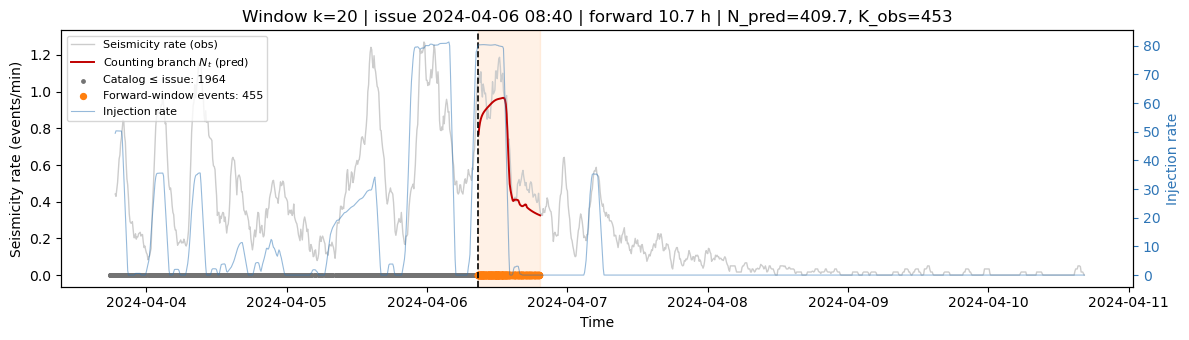

In [27]:
k = 20    

e = sp_eval[k]
hist_sr = meta['seismic_rate'] * norm_stats['seismic_rate'][1] + norm_stats['seismic_rate'][0]
hist_inj = meta['injection_rate'] * norm_stats['injection_rate'][1] + norm_stats['injection_rate'][0]
dec_dates = pd.to_datetime(results[k]['date'][n_enc_sp:])
t_issue, fw_end = e['t_issue'], e['fw_end']

ct = sp_catalog['times']
train_ev = ct <= t_issue.to_datetime64()
fw_ev = (ct > t_issue.to_datetime64()) & (ct <= fw_end.to_datetime64())

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(meta['time_axis'], hist_sr, color='0.8', lw=1, label='Seismicity rate (obs)')
ax.plot(dec_dates, e['pred'], color='#c00000', lw=1.4, label='Counting branch $N_t$ (pred)')
y0 = float(hist_sr.min())
ax.scatter(ct[train_ev], np.full(int(train_ev.sum()), y0), s=6, c='0.45',
           label=f'Catalog ≤ issue: {int(train_ev.sum())}')
ax.scatter(ct[fw_ev], np.full(int(fw_ev.sum()), y0), s=18, c='#ff7f0e',
           label=f'Forward-window events: {int(fw_ev.sum())}')
ax.axvline(t_issue, color='k', lw=1.2, linestyle='--')
ax.axvspan(t_issue, fw_end, color='#ff7f0e', alpha=0.10)
ax.set_ylabel('Seismicity rate (events/min)')
ax.set_xlabel('Time')

ax2 = ax.twinx()
ax2.plot(meta['time_axis'], hist_inj, color='#2e75b6', lw=0.8, alpha=0.5, label='Injection rate')
ax2.set_ylabel('Injection rate', color='#2e75b6')
ax2.tick_params(axis='y', colors='#2e75b6')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
ax.set_title(f"Window k={k} | issue {t_issue.strftime('%Y-%m-%d %H:%M')} | "
             f"forward {H * bin_mins / 60:.1f} h | N_pred={e['N_pred']:.1f}, K_obs={e['K']}")
plt.tight_layout()
plt.show()

vmax: 10
normalized sum=1.000000 | common vmax(99%)=10.000000 | 50% HDR threshold=0.012643 | 80% HDR threshold=0.004288


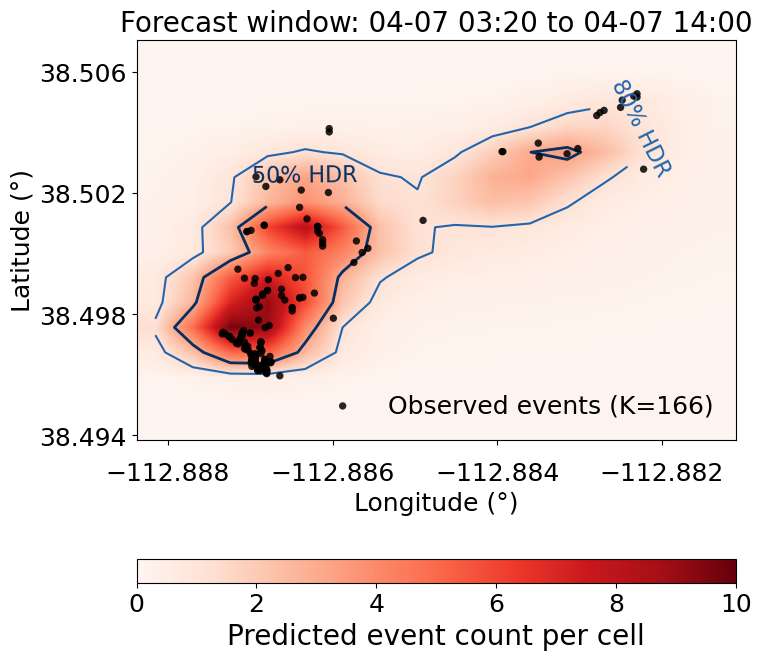

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

k = 160
fontsize = 18
mpl.rcdefaults()
mpl.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "legend.fontsize": fontsize,
})

e = sp_eval[k]
lon_edges = np.asarray(sw_grid["lon_edges"])
lat_edges = np.asarray(sw_grid["lat_edges"])
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
prob = np.asarray(e["sw_fc"], dtype=np.float64).reshape(n_grid, n_grid)
prob = np.clip(prob, 0.0, None)
prob /= prob.sum()
lam = e["N_pred"] * prob

vmax = np.percentile(lam[lam > 0], 99)
vmax = 10
print(f"vmax: {vmax}")

fw_ev = (
    (cat_times > e["t_issue"].to_datetime64())
    & (cat_times <= e["fw_end"].to_datetime64())
)


fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
im = ax.imshow(
    lam,
    extent=(lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]),
    origin="lower",
    cmap="Reds",
    vmin=0.0,
    vmax=vmax,
    interpolation="bilinear",
    aspect="auto",
    zorder=2,
)

# 50%/80% highest-density-region (HDR) boundaries.
_flat = prob.ravel()
_order = np.argsort(_flat)[::-1]
_cumulative = np.cumsum(_flat[_order])
def _hdr_threshold(mass):
    return float(_flat[_order[min(np.searchsorted(_cumulative, mass), len(_order) - 1)]])
_t50, _t80 = _hdr_threshold(0.50), _hdr_threshold(0.80)
_levels = sorted(set([_t80, _t50]))
if len(_levels) == 2:
    _cs = ax.contour(
        lon_centers, lat_centers, prob,
        levels=_levels,
        colors=["#2166ac", "#053061"],
        linewidths=[1.5, 2.0],
        zorder=4,
    )
    ax.clabel(_cs, fmt={_t80: "80% HDR", _t50: "50% HDR"}, fontsize=16)

ax.scatter(
    cat_lons[fw_ev], cat_lats[fw_ev],
    s=28, c="k", marker="o", alpha=0.85,
    edgecolors="none", linewidths=0.4, zorder=5,
    label=f"Observed events (K={int(fw_ev.sum())})",
)
ax.set_xlim(lon_edges[0], lon_edges[-1])
ax.set_ylim(lat_edges[0], lat_edges[-1])
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
ax.set_title(
    f'Forecast window: '
    f'{e["t_issue"].strftime("%m-%d %H:%M")} to '
    f'{e["fw_end"].strftime("%m-%d %H:%M")}',
    fontsize=fontsize + 2,
)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.legend(loc="lower right", frameon=False)
cbar = fig.colorbar(
    im, ax=ax, orientation="horizontal", location="bottom",
    fraction=0.08, pad=0.10, aspect=25,
)
# cbar.set_label("Forecast spatial probability", fontsize=fontsize + 2)
cbar.set_label(
    "Predicted event count per cell",
    fontsize=fontsize + 2,
)
cbar.ax.tick_params(labelsize=fontsize)

xticks = ax.get_xticks(); xlim = ax.get_xlim()
ax.set_xticks(xticks[(xticks >= xlim[0]) & (xticks <= xlim[1])])
yticks = ax.get_yticks(); ylim = ax.get_ylim()
yticks = yticks[(yticks >= ylim[0]) & (yticks <= ylim[1])]
ax.set_yticks(yticks[::2])
cbar_ticks = cbar.get_ticks()
cbar_ticks = cbar_ticks[(cbar_ticks >= im.norm.vmin) & (cbar_ticks <= im.norm.vmax)]
cbar.set_ticks(cbar_ticks[::1])
ax.tick_params(axis="x", pad=12)

print(f"normalized sum={prob.sum():.6f} | common vmax(99%)={vmax:.6f} | "
      f"50% HDR threshold={_t50:.6f} | 80% HDR threshold={_t80:.6f}")
plt.show()


## Single Sample Visualization

In [29]:
results = results_sets['current']
k = 20
result_dict = results[k]
this_time_axis = result_dict['date']
this_injection_rate = result_dict['injection_rate']
this_pressure = result_dict['pressure']
this_seismic_rate = result_dict['seismic_rate']
seismic_rate_target = result_dict['target']
seismic_rate_prediction = result_dict['prediction']
target_index = result_dict['target_index']
this_group_id = result_dict['group_id']

print(f"forcasting time: {zero_date}")
print(f"prediction time: {this_time_axis[max_encoder_length]}")

all_index = np.arange(len(this_time_axis))
input_axis = np.array([j for j in all_index if j not in target_index])
input_axis = input_axis[-max_prediction_length*2:]

forcasting time: 2024-04-06 06:06:00
prediction time: 2024-04-06 08:48:00


In [30]:
merges = utils.merge_and_evaluate_forecasts(results, time_axis_all)

seismic_rate_all_raw = meta['seismic_rate'] * norm_stats['seismic_rate'][1] + norm_stats['seismic_rate'][0]
injection_rate_all_raw = meta['injection_rate'] * norm_stats['injection_rate'][1] + norm_stats['injection_rate'][0]
pressure_all_raw = meta['pressure'] * norm_stats['pressure'][1] + norm_stats['pressure'][0]

seismic_rate_pred = merges['seismic_rate_pred']
seismic_rate_tgt = merges['seismic_rate_tgt']
global_index = merges['global_index']
global_index_inp = merges['global_index_inp']
time_axis_tgt = merges['time_axis_tgt']
time_axis_inp = merges['time_axis_inp']

1st Y-axis range: (np.float64(0.0), np.float64(1.6))
2nd Y-axis range: (np.float64(-5.0), np.float64(85.0))
3rd Y-axis range: (np.float64(-370.0), np.float64(8330.0))


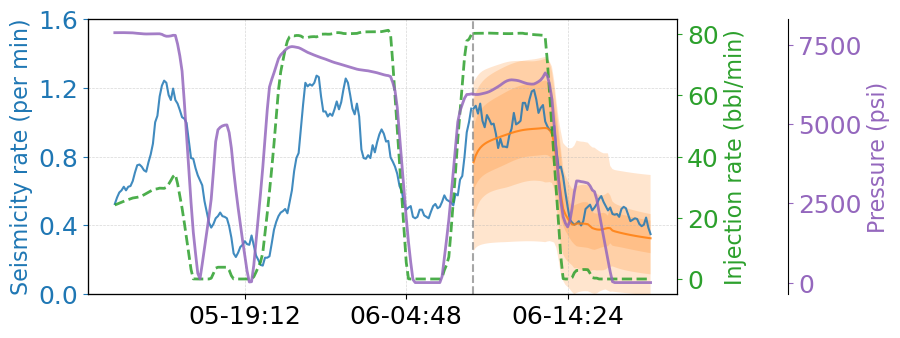

In [34]:
ylims=[
    (0.0, 1.6),
    (-5, 85),
    (-370, 8330)
]
draw1.draw_sequence_diff(
    [
        [
            [this_time_axis[input_axis], this_time_axis[target_index], this_time_axis[target_index]],
            [this_seismic_rate[input_axis], seismic_rate_target, seismic_rate_prediction.mean(axis=-1)],
        ],       
        [
            [this_time_axis[input_axis], this_time_axis[target_index]], 
            [this_injection_rate[input_axis], this_injection_rate[target_index]],
        ],
        [
            [this_time_axis[input_axis], this_time_axis[target_index]], 
            [this_pressure[input_axis], this_pressure[target_index]],
        ],
    ],
    mark_datetime = [this_time_axis[target_index[0]]],
    ylims=ylims,
    uncertainty=[
        [[this_time_axis[target_index]],
        [seismic_rate_prediction.T]],
    ],
    labels = ['Seismicity rate (per min)', 'Injection rate (bbl/min)', 'Pressure (psi)'],
    figsize=(9,4),
    nax = 4,
    nay = [4,5,4],
    time_format='dhm',
    legend=False,
    fontsize=16,
    types=['line', 'line', 'line'],
    linestyles=[['-','-','-'],['--','--'],['-','-']],
    ucolor=[["#ff7f0e"]],
    lcolor = [["#1f77b4"]*2+['#ff7f0e'], ["#2ca02c", "#2ca02c", "#2ca02c"], ["#9467bd", "#9467bd"], ["#e15759", "#e15759"]] 
) 

1st Y-axis range: (np.float64(-0.06795146656298788), np.float64(1.4269807978227453))
2nd Y-axis range: (np.float64(-4.065535173611112), np.float64(85.37623864583334))
3rd Y-axis range: (np.float64(-408.97614236111116), np.float64(8588.498989583333))


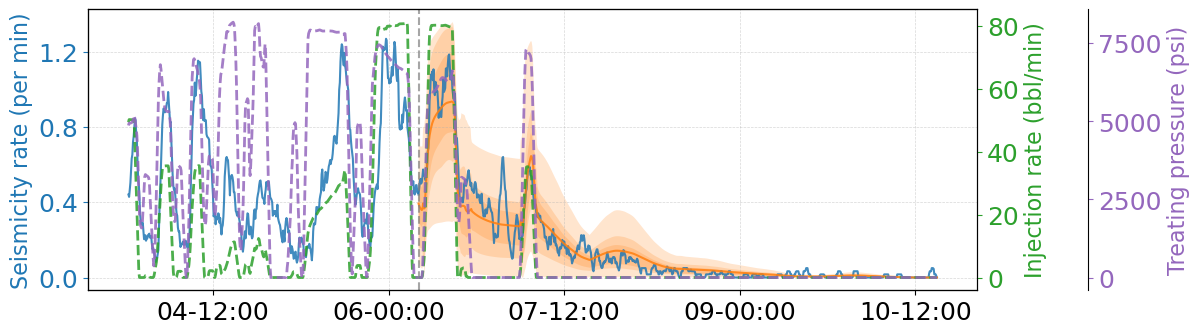

In [32]:
draw1.draw_sequence_diff(
    [
        [
            [time_axis_inp, time_axis_tgt, time_axis_tgt],
            [seismic_rate_all_raw[global_index_inp], seismic_rate_tgt, seismic_rate_pred.mean(axis=-1)],
        ],  
        [
            [time_axis_inp, time_axis_tgt], 
            [injection_rate_all_raw[global_index_inp], injection_rate_all_raw[global_index]],
        ],
        [
            [time_axis_inp, time_axis_tgt], 
            [pressure_all_raw[global_index_inp], pressure_all_raw[global_index]],
        ],
    ],
    mark_datetime = [time_axis_tgt[0]],
    uncertainty=[
        [
            [time_axis_tgt],
            [seismic_rate_pred.T],
        ],
    ],
    labels = ['Seismicity rate (per min)', 'Injection rate (bbl/min)', 'Treating pressure (psi)'],
    figsize=(12,4),
    nax = 6,
    nay = [4,5,4],
    time_format='dhm',
    legend=False,
    fontsize=16,
    types=['line', 'line', 'line'],
    linestyles=[['-','-','-'],['--','--'],['--','--']],
    ucolor=[["#ff7f0e", "#a9a9a9"]],
    lcolor = [["#1f77b4"]*2+['#ff7f0e'], ["#2ca02c", "#2ca02c", "#2ca02c"], ["#9467bd", "#9467bd", "#e15759"]],
    align_zero=True, clip_unc_zero=True,
)

1st Y-axis range: (np.float64(-0.06795146656298788), np.float64(1.4269807978227453))
2nd Y-axis range: (np.float64(-4.065535173611112), np.float64(85.37623864583334))
3rd Y-axis range: (np.float64(-408.97614236111116), np.float64(8588.498989583333))


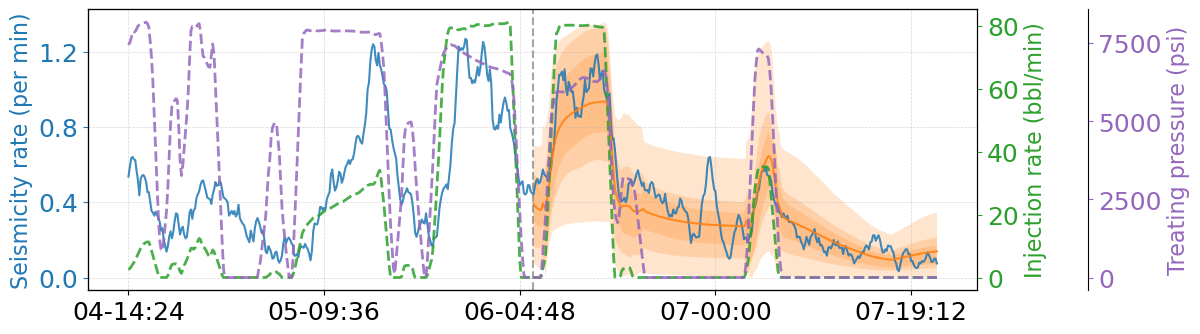

In [33]:
s1 = 298
draw1.draw_sequence_diff(
    [
        [
            [time_axis_inp[-s1:], time_axis_tgt[:s1], time_axis_tgt[:s1]],
            [seismic_rate_all_raw[global_index_inp][-s1:], seismic_rate_tgt[:s1,:], seismic_rate_pred.mean(axis=-1)[:s1]],
        ],  
        [
            [time_axis_inp[-s1:], time_axis_tgt[:s1]], 
            [injection_rate_all_raw[global_index_inp][-s1:], injection_rate_all_raw[global_index][:s1]],
        ],
        [
            [time_axis_inp[-s1:], time_axis_tgt[:s1]], 
            [pressure_all_raw[global_index_inp][-s1:], pressure_all_raw[global_index][:s1]],
        ],
    ],
    mark_datetime = [time_axis_tgt[0]],
    uncertainty=[
        [
            [time_axis_tgt[:s1]],
            [seismic_rate_pred.T[:,:s1]],
        ],
    ],
    labels = ['Seismicity rate (per min)', 'Injection rate (bbl/min)', 'Treating pressure (psi)'],
    figsize=(12,4),
    nax = 6,
    nay = [4,5,4],
    time_format='dhm',
    legend=False,
    fontsize=16,
    types=['line', 'line', 'line'],
    linestyles=[['-','-','-'],['--','--'],['--','--']],
    ucolor=[["#ff7f0e", "#a9a9a9"]],
    lcolor = [["#1f77b4"]*2+['#ff7f0e'], ["#2ca02c", "#2ca02c", "#2ca02c"], ["#9467bd", "#9467bd", "#e15759"]],
    align_zero=True, clip_unc_zero=True,
)